In [1]:
using Base.Threads
println( "Number of threads: ", nthreads() )

include( "../args.jl" )
include( "../model.jl" )

Number of threads: 24
Loaded network.jl class file.
Loaded model.jl class file.


In [2]:
# Default simulation parameters.
ρ = 0.1;  γ = 0.1;  τ = 75.0;  ξ = 10.0^-1
params = Params(; ρ=ρ, γ=γ, τ=τ, ξ=ξ )

Params(1.0, 0.1, 0.1, 0.0, 75.0, 0.1, 0.5, 0.0, 0.5, 0.25, 10.0, 1.0, 0.7853981633974483, LogNormal{Float64}(μ=-2.4141568686511503, σ=0.47238072707743883), Truncated(Laplace{Float64}(μ=0.0, θ=0.5); lower=-3.141592653589793, upper=3.141592653589793))

In [3]:
# Varying system parameters.
μ = 1.0
N = defInt( 100 )
L = √(N/μ)

# Data folder name.
case = "../data/results/case-0/"
folder = case*"N-$(N)/mu-$(round( μ, digits=3 ))_xi-$(round( ξ, digits=5 ))/"

"../data/results/case-0/N-100/mu-1.0_xi-0.1/"

In [4]:
# Simulation length and replicates.
T = τ;  M = 250

# Import activation order data.
hdata = round.( defInt, readdlm( folder*"activation-order.txt" ) )

# Import activation data.
ndata = round.( defInt, readdlm( folder*"outgoing-activations.txt" ) )
n̂data = round.( defInt, readdlm( folder*"incoming-activations.txt" ) )

# Import tree depth data.
ddata = round.( defInt, readdlm( folder*"tree-depth-min.txt" ) )
d̂data = round.( defInt, readdlm( folder*"tree-depth-max.txt" ) );

In [5]:
# Aggregate connections.
nlist = vcat( ndata... );  nmax = maximum( nlist )

# Computed probability mass.
nbins = -1/2:(nmax+1/2)
Hn = fit( Histogram, nlist, nbins )

# Weight frequencies.
xlist = defInt.( nbins[1:end-1] .+ 1/2 )
plist = Hn.weights/sum( Hn.weights );

In [6]:
# Collect indeces of agents who were activated.
hlist = vcat( hdata... )
ilist = hlist .== -1

# Compute the node-depth distribution.
dlist = vcat( d̂data... );  dlist[ilist] .= 0;

In [7]:
# Extract bins and corresponding nunber of activations.
dmax = maximum( dlist );  dbins = 1:dmax
n̂list = [nlist[dlist .== d] for d ∈ dbins]

# Compute mean and mean difference.
n̂mean = mean.( n̂list )
n̂lower = [mean( n̄ .- n̂[n̂ .< n̄] ) for (n̄, n̂) ∈ zip( n̂mean, n̂list )]
n̂upper = [mean( n̂[n̂ .> n̄] .- n̄ ) for (n̄, n̂) ∈ zip( n̂mean, n̂list )]

# Computed probability mass and normalize.
Hd = fit( Histogram, dlist, [dbins .- 1/2; dmax+1/2] )
pdlist = Hd.weights/sum( Hd.weights );

In [8]:
# Bin by activation order (ignore agents that never activated).
h̃max = maximum( hlist );  h̃bins = 1:h̃max
ñlist = [nlist[hlist .== h̃] for h̃ ∈ h̃bins];

# Compute mean of each bin.
ñmean = mean.( ñlist );

In [9]:
println( μ*params.β/params.ρ*sin( params.α ) )

7.071067811865475


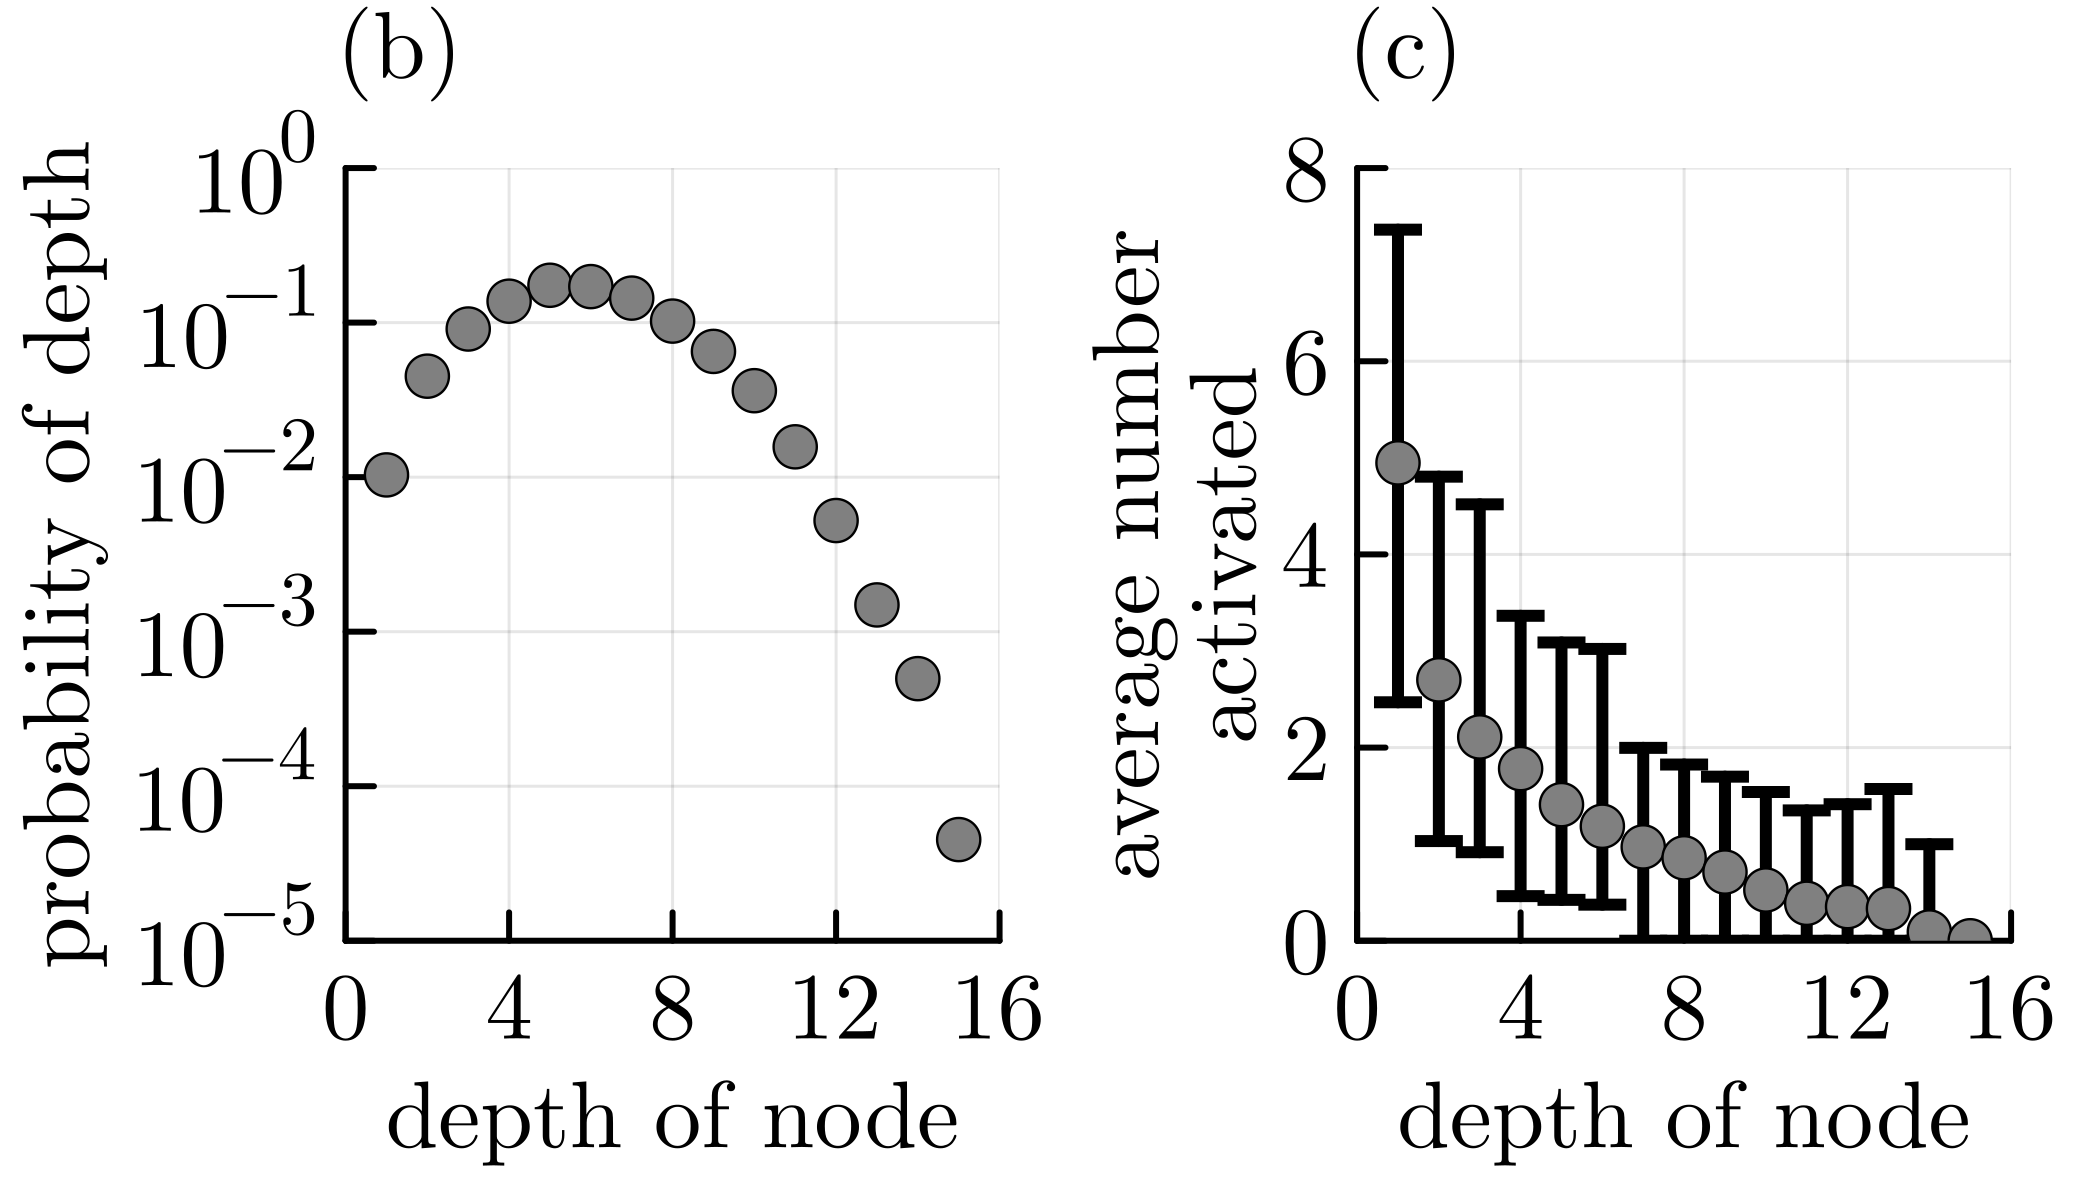

In [10]:
# Initialize plot variable.
plt = plot( layout=(1,2), size=(350,200), xformatter=:plain, margin=10pt, dpi=600 )
plot!( plt; left_margin=0pt, bottom_margin=5pt )

# Plot the distribution of node depths.
jlist = pdlist .> 0
scatter!( plt[1], dbins[jlist], pdlist[jlist]; color=:gray, label="" )

Δx = 4;  xmax = Δx*floor( 1.1dmax/Δx )
ymin = floor( minimum( log10.( pdlist[jlist] ) ) )
plot!( plt[1]; xlims=(0,xmax), xticks=0:Δx:xmax )
plot!( plt[1]; ylims=(10^ymin,1), yscale=:log10 )

plot!( plt[1]; xlabel="depth of node", ylabel="probability of depth" )
title!( plt[1], "(b)"; title_position=:left )

# Plot the depth of the node against the number of activations.
scatter!( plt[2], dbins, n̂mean; yerror=(n̂lower, n̂upper), color=:gray, lw=2, marker=:circ, label="" )

Δx = 4;  xmax = Δx*floor( 1.1dmax/Δx )
Δy = 2;  ymax = 8
plot!( plt[2]; xlims=(0,xmax), xticks=0:Δx:xmax )
plot!( plt[2]; ylims=(0,ymax), yticks=0:Δy:ymax )

plot!( plt[2]; xlabel="depth of node", ylabel="average number\nactivated", legend=:topright )
title!( plt[2], "(c)"; title_position=:left )

saveplot( plt, figurefolder*"activation-graph-statistics_N-$(N).png" )